In [147]:
from models import BoundsDetector
from models import ProbabilisticStuckSignalDetector, StuckSignalDetector
from models import RobustRollingOutlierLookahead

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Выход значения за физические границы (границы задаются пользователем — метаданные)

In [148]:
rules = {'temp': (10, 30), 'volt': (110, 120)}

model = BoundsDetector(bounds=rules)

# Works with DataFrames (any column order)
df = pd.DataFrame({'volt': [115, 125], 'temp': [25, 35]})
model.fit(df)
assert (model.predict(df) == np.asarray([
    [0, 0],
    [1, 1]
])).all()

# Works with Arrays (assuming position matches the dict order)
arr = np.array([[115, 25], [125, 35]]) 
predicted = model.predict(arr)
assert (predicted == np.asarray([
    [0, 0],
    [1, 1]
])).all()

In [149]:
bounds_config = {
    "Temperature": (18.0, 26.0),
    "Pressure": (1000.0, 1030.0)
}
model = BoundsDetector(bounds=bounds_config)

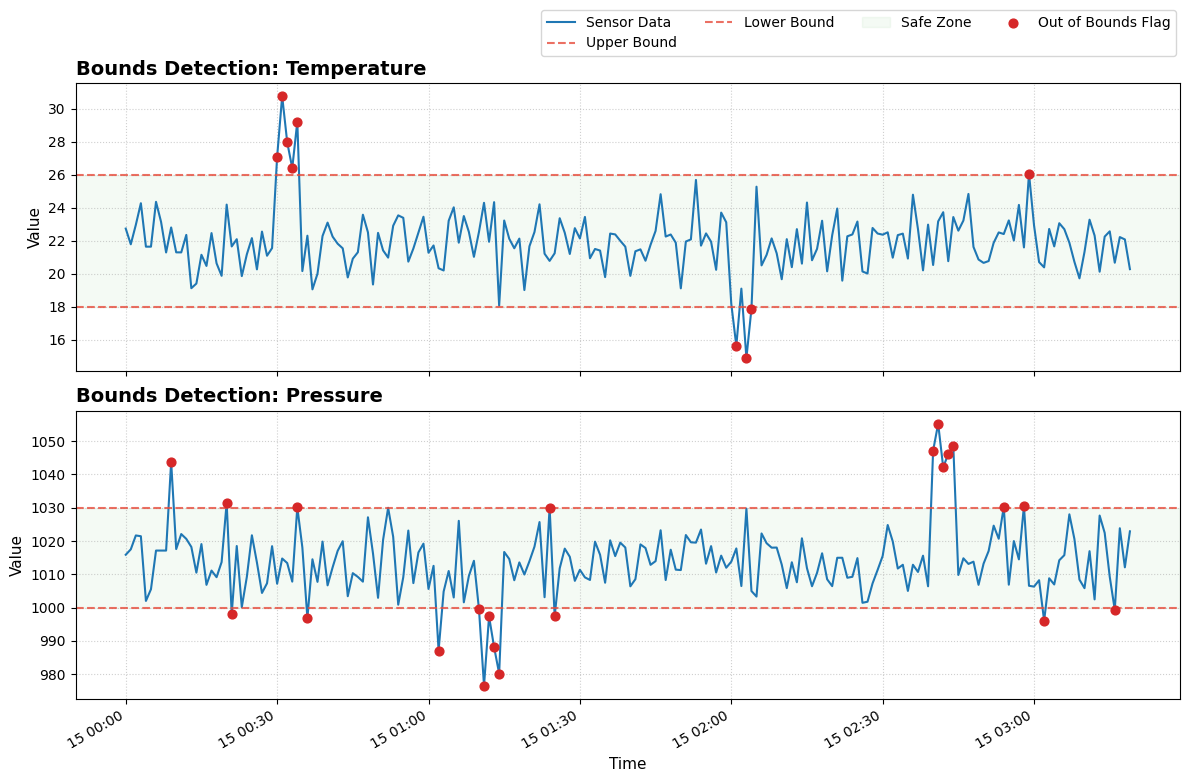

In [150]:
# -------------------------------------------------------------------------
# 1. Simulate Time Series Data
# -------------------------------------------------------------------------
np.random.seed(42)
n_samples = 200
timestamps = pd.date_range(start="2026-05-15 00:00", periods=n_samples, freq="min")

# Generate two features: Temperature and Pressure
temperature = 22 + np.random.normal(0, 1.5, size=n_samples)
pressure = 1013 + np.random.normal(0, 8, size=n_samples)

# Inject some explicit out-of-bounds anomalies
temperature[30:35] += 6.0    # High spikes
temperature[120:125] -= 5.0  # Low spikes
pressure[70:75] -= 25.0      # Low dip
pressure[160:165] += 30.0    # High spike

df = pd.DataFrame({"Temperature": temperature, "Pressure": pressure}, index=timestamps)

# -------------------------------------------------------------------------
# 2. Initialize and Run your BoundsDetector
# -------------------------------------------------------------------------
# Define threshold ranges

model.fit(df)
anomalies_matrix = model.predict(df)

# Convert predictions back to a DataFrame for easy indexing
df_anomalies = pd.DataFrame(anomalies_matrix, columns=df.columns, index=df.index)

# -------------------------------------------------------------------------
# 3. Create the Matplotlib Visualization
# -------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

for ax, col in zip(axes, df.columns):
    # Plot the continuous time series line
    ax.plot(df.index, df[col], color="#1f77b4", linewidth=1.5, label="Sensor Data")
    
    # Extract configured bounds
    low_bound, high_bound = bounds_config[col]
    
    # Draw the boundary thresholds
    ax.axhline(high_bound, color="#e74c3c", linestyle="--", alpha=0.8, label="Upper Bound")
    ax.axhline(low_bound, color="#e74c3c", linestyle="--", alpha=0.8, label="Lower Bound")
    
    # Shade the "Safe Zone" in a very light grey/green
    ax.axhspan(low_bound, high_bound, color="#2ca02c", alpha=0.05, label="Safe Zone")
    
    # Highlight the anomalies (where detector returned 1)
    anomaly_indices = df_anomalies[df_anomalies[col] == 1].index
    ax.scatter(anomaly_indices, df.loc[anomaly_indices, col], 
               color="#d62728", s=40, zorder=5, label="Out of Bounds Flag")
    
    # Styling details
    ax.set_title(f"Bounds Detection: {col}", fontsize=14, fontweight="bold", loc="left")
    ax.set_ylabel("Value", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)

# Refine x-axis labels formatting
plt.gcf().autofmt_xdate()
axes[-1].set_xlabel("Time", fontsize=11)

# Deduplicate legend items and place neatly
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(0.99, 0.98), ncol=4)

plt.tight_layout()
plt.subplots_adjust(top=0.88) # Make space for global legend
plt.show()

# Точечные выбросы (не смена режима)

In [151]:
model = RobustRollingOutlierLookahead(window=25, sigma_cutoff=3, sensitivity=1.5) # не смена режима

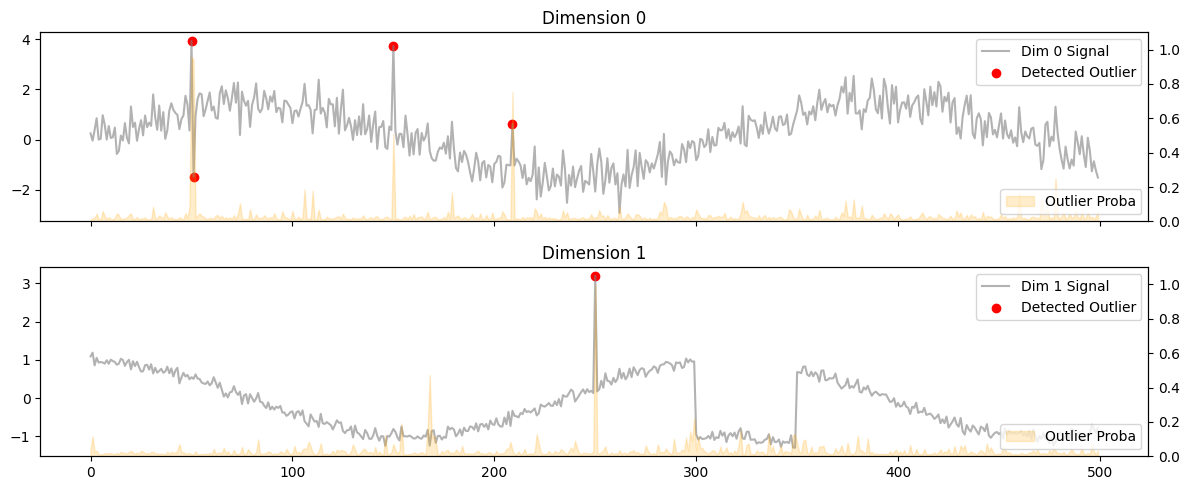

Probabilities at index 50 (Spike): [0.9580416  0.01161832]
Probabilities at index 10 (Normal): [0.01329179 0.01940509]


In [152]:
# --- Generate Synthetic Multi-Dim Data ---
np.random.seed(42)
n_points = 500

# Create a baseline that wanders (not a flat line)
time = np.linspace(0, 10, n_points)
baseline_dim1 = 1.5 * np.sin(time)
baseline_dim2 = np.cos(time)

# Add heavy-tailed noise (non-normal: Cauchy-like or high-variance)
noise_dim1 = np.random.normal(0, 0.5, n_points)
noise_dim2 = np.random.normal(0, 0.1, n_points)

data = np.stack([baseline_dim1 + noise_dim1, baseline_dim2 + noise_dim2], axis=1)

# Inject random sharp spikes
data[50, 0] += 2.5  # Positive spike
data[51, 0] += -2.56 # Positive spike
data[150, 0] += 3.4 # Negative spike
data[250, 1] += 3.0 # Spike in second dimension
data[300:350, 1] -= 2. # change in mode

# --- Detect Outliers ---

probabilities = model.predict_proba(data)

# --- Visualization ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for i in range(2):
    axes[i].plot(data[:, i], label=f'Dim {i} Signal', color='gray', alpha=0.6)
    
    # Scatter plot where probability is high
    mask = probabilities[:, i] > 0.5
    axes[i].scatter(np.where(mask)[0], data[mask, i], color='red', label='Detected Outlier')
    
    # Probability secondary axis
    ax_prob = axes[i].twinx()
    ax_prob.fill_between(range(n_points), 0, probabilities[:, i], color='orange', alpha=0.2, label='Outlier Proba')
    ax_prob.set_ylim(0, 1.1)
    
    axes[i].set_title(f"Dimension {i}")
    ax_prob.legend(loc='lower right')
    axes[i].legend(loc='upper right')
# plt.legend()
plt.tight_layout()
plt.show()

# Sample output for a specific point
print(f"Probabilities at index 50 (Spike): {probabilities[50]}")
print(f"Probabilities at index 10 (Normal): {probabilities[10]}")

# Зависание сигнала (отсутствие шума/изменений в течение заданного окна)

In [153]:
model = StuckSignalDetector(window_size=5, threshold=1e-3, metric='mad')

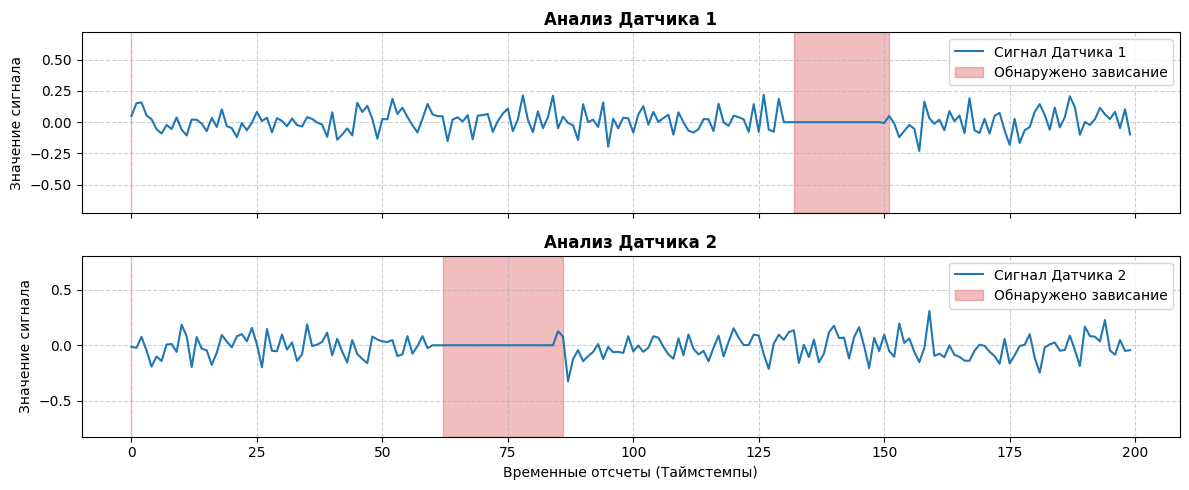

In [154]:
# 1. Генерируем тестовые данные (многомерный ряд)
np.random.seed(42)
n_points = 200
time_series = np.random.normal(0, 0.1, size=(n_points, 3)) # 3 компоненты с шумом

# Симулируем зависания:
time_series[130:150, 0] = 0.0    # Первая компонента зависла на значении 5.0
time_series[60:85, 1] = 0   # Вторая компонента зависла на значении -2.1
# Третья компонента осталась нормальной (просто шум)

# 2. Инициализируем и применяем модель в стиле sklearn

model.fit(time_series[:50])
anomalies = model.predict(time_series)



fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
time_axis = np.arange(n_points)

for i in range(2):
    ax = axes[i]
    signal = time_series[:, i]
    anomaly_mask = anomalies[:, i]
    
    # Рисуем основной сигнал (синяя линия)
    ax.plot(time_axis, signal, label=f'Сигнал Датчика {i+1}', color='#1f77b4', linewidth=1.5)
    
    # Подсвечиваем зоны зависания красным фоном (где аномалия == 1)
    # Используем fill_between для выделения областей
    ax.fill_between(time_axis, min(signal)-0.5, max(signal)+0.5, 
                    where=anomaly_mask == 1, 
                    color='#d62728', alpha=0.3, label='Обнаружено зависание')
    
    # Стилизация графика
    ax.set_title(f'Анализ Датчика {i+1}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение сигнала', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_ylim(min(signal) - 0.5, max(signal) + 0.5)

# Общая настройка осей
axes[1].set_xlabel('Временные отсчеты (Таймстемпы)', fontsize=10)
# plt.suptitle('Детекция зависания сигнала (Stuck Signal Detection) через Скользящее Окно', fontsize=14, y=0.95)

plt.tight_layout()
plt.show()

In [155]:
model = ProbabilisticStuckSignalDetector(window_size=15, expected_noise=0.3, decision_threshold=0.7)

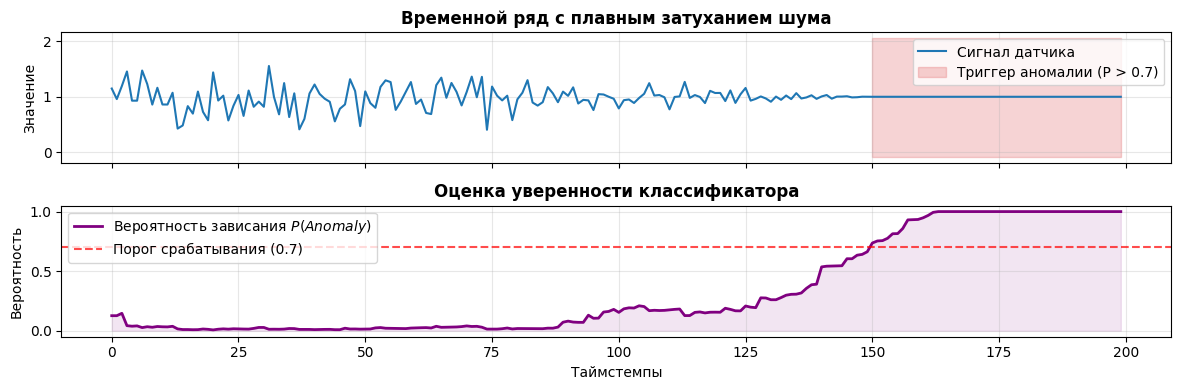

In [156]:
# 1. Генерируем сигнал, который постепенно теряет амплитуду (затухает в константу)
np.random.seed(42)
n_points = 200
time_axis = np.arange(n_points)

# Нормальный шум
noise = np.random.normal(0, 0.3, size=n_points)
# Коэффициент затухания, который после 50 точки плавно сжимает шум в ноль к 130 точке
decay = np.ones(n_points)
decay[50:150] = np.linspace(1.0, 0.0, 100)
decay[150:] = 0.0

signal = (noise * decay + 1.0).reshape(-1, 1) # Сдвинем вверх для наглядности

# 2. Обучаем и применяем вероятностную модель
# Задаем ожидаемый шум 0.3 (как при генерации)

model.fit(signal)

probabilities = model.predict_proba(signal)[:, 0]
predictions = model.predict(signal)[:, 0]

# 3. Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

# Верхний график: Сам сигнал и бинарная маска
ax1.plot(time_axis, signal[:, 0], color='#1f77b4', label='Сигнал датчика')
ax1.fill_between(time_axis, min(signal[:,0])-0.5, max(signal[:,0])+0.5, 
                where=predictions == 1, color='#d62728', alpha=0.2, label='Триггер аномалии (P > 0.7)')
ax1.set_title('Временной ряд с плавным затуханием шума', fontsize=12, fontweight='bold')
ax1.set_ylabel('Значение')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Нижний график: Изменение уверенности модели (Вероятности)
ax2.plot(time_axis, probabilities, color='purple', linewidth=2, label='Вероятность зависания $P(Anomaly)$')
ax2.axhline(0.7, color='red', linestyle='--', alpha=0.7, label='Порог срабатывания (0.7)')
ax2.fill_between(time_axis, 0, probabilities, color='purple', alpha=0.1)
ax2.set_title('Оценка уверенности классификатора', fontsize=12, fontweight='bold')
ax2.set_xlabel('Таймстемпы')
ax2.set_ylabel('Вероятность')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [157]:
model = ProbabilisticStuckSignalDetector(window_size=15, expected_noise=0.3, decision_threshold=0.7)

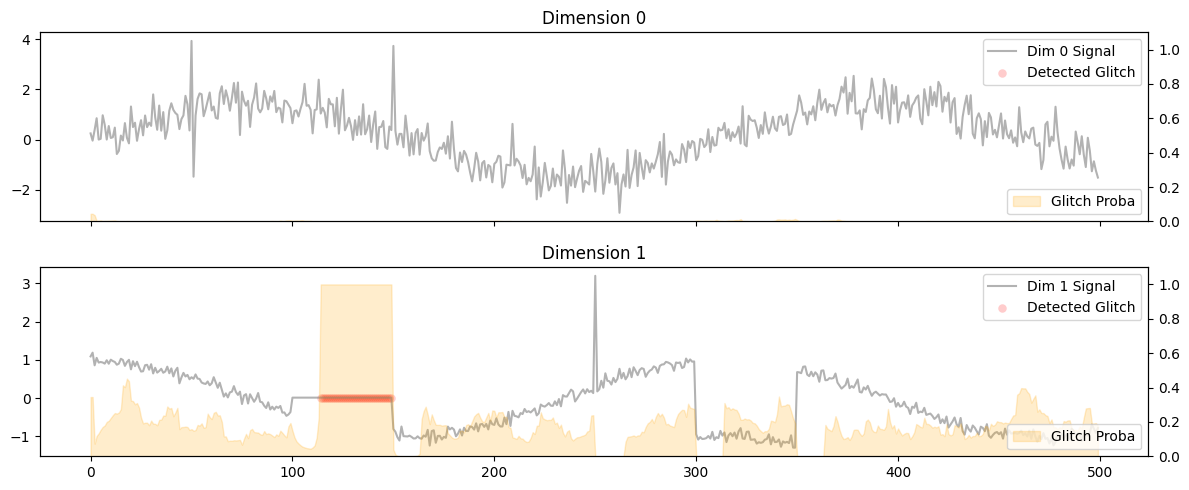

Probabilities at index 50 (Spike): [9.70172938e-07 1.58194290e-01]
Probabilities at index 10 (Normal): [0.00385887 0.22273507]


In [158]:
# --- Generate Synthetic Multi-Dim Data ---
np.random.seed(42)
n_points = 500

# Create a baseline that wanders (not a flat line)
time = np.linspace(0, 10, n_points)
baseline_dim1 = 1.5 * np.sin(time)
baseline_dim2 = np.cos(time)

# Add heavy-tailed noise (non-normal: Cauchy-like or high-variance)
noise_dim1 = np.random.normal(0, 0.5, n_points)
noise_dim2 = np.random.normal(0, 0.1, n_points)

data = np.stack([baseline_dim1 + noise_dim1, baseline_dim2 + noise_dim2], axis=1)

# Inject random sharp spikes
data[50, 0] += 2.5  # Positive spike
data[51, 0] += -2.56 # Positive spike
data[150, 0] += 3.4 # Negative spike
data[250, 1] += 3.0 # Spike in second dimension
data[300:350, 1] -= 2. # change in mode
data[100:150, 1] = np.random.normal(0, 0.01)

# --- Detect Outliers ---

model.fit(data[:50])

probabilities = model.predict_proba(data)

# --- Visualization ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for i in range(2):
    axes[i].plot(data[:, i], label=f'Dim {i} Signal', color='gray', alpha=0.6)
    
    # Scatter plot where probability is high
    mask = probabilities[:, i] > 0.5
    axes[i].scatter(np.where(mask)[0], data[mask, i], color='red', label='Detected Glitch', lw=0.05, alpha=0.2)
    
    # Probability secondary axis
    ax_prob = axes[i].twinx()
    ax_prob.fill_between(range(n_points), 0, probabilities[:, i], color='orange', alpha=0.2, label='Glitch Proba')
    ax_prob.set_ylim(0, 1.1)
    
    axes[i].set_title(f"Dimension {i}")
    ax_prob.legend(loc='lower right')
    axes[i].legend(loc='upper right')
# plt.legend()
plt.tight_layout()
plt.show()

# Sample output for a specific point
print(f"Probabilities at index 50 (Spike): {probabilities[50]}")
print(f"Probabilities at index 10 (Normal): {probabilities[10]}")